#Project Overview

This project explores household survey data using Python, pandas, SQLite, and SQL queries within a Google Colab environment.

The analysis focuses on household demographics, technology access, income levels, and financial hardship indicators among surveyed households in Bulacan. The project includes data exploration, filtering, and visualization techniques to identify trends and patterns within the dataset.

# Technologies Used
- Python
- pandas
- sqlite3
- matplotlib
- Google Colab

#Data Loading

Loading data from Survey.csv into pandas, connecting to a new Survey_Database.db, and loading the survey data into a new table named Initial_Table.

In [3]:
import pandas as pd
import sqlite3

survey = pd.read_csv('/content/Survey.csv')

conn = sqlite3.connect('Survey_Database.db')

survey.to_sql('Initial_Table', conn, if_exists = 'replace', index = False)

116

#Exploratory Data Analysis

Reviewing columns of the survey data.

In [4]:
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 23 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Timestamp                                    116 non-null    object 
 1   Name                                         0 non-null      float64
 2   Age                                          115 non-null    float64
 3   Sex                                          116 non-null    object 
 4   MobileNumber                                 0 non-null      float64
 5   IsFromBulacan                                116 non-null    object 
 6   IsLivingWithExtendedFamily                   112 non-null    object 
 7   HouseholdMemberCount                         112 non-null    float64
 8   IsStudentInHousehold                         112 non-null    object 
 9   HouseholdMembersContributingToBillsCount     112 non-null    float64
 10  Ho

Creating a new table named Initial_Table2.

In [5]:
query = """
CREATE TABLE Initial_Table2 AS
SELECT Age, Sex, IsFromBulacan,
       IsLivingWithExtendedFamily, HouseholdMemberCount,
       IsStudentInHousehold, HouseholdMembersContributingToBillsCount,
       HouseholdMonthlySalaryRange, IsHouseholdGettingFinancialAssistance,
       HouseholdElectricityBudget, OwnedAppliances,
       ElectricityBillAmountForMonthA, ElectricityBillAmountForMonthB,
       ElectricityBillAmountForMonthC,
       HouseholdFinancialAssistanceAmountRange,
       HouseholdFinancialAssistanceFrequency, StudentInHouseholdCount,
       HouseholdStudentsHave, StruggleToFindMoneyForElectricBillFrequency,
       MonthlyElectricBillPayFailureFrequency
FROM Initial_Table;
"""
conn.execute(query)

Getting households from Bulacan.

In [6]:
query = """
SELECT *
FROM Initial_Table2
WHERE IsFromBulacan = 'Yes';
"""
df = pd.read_sql(query, conn)
df

,Age,Sex,IsFromBulacan,IsLivingWithExtendedFamily,HouseholdMemberCount,IsStudentInHousehold,HouseholdMembersContributingToBillsCount,HouseholdMonthlySalaryRange,IsHouseholdGettingFinancialAssistance,HouseholdElectricityBudget,OwnedAppliances,ElectricityBillAmountForMonthA,ElectricityBillAmountForMonthB,ElectricityBillAmountForMonthC,HouseholdFinancialAssistanceAmountRange,HouseholdFinancialAssistanceFrequency,StudentInHouseholdCount,HouseholdStudentsHave,StruggleToFindMoneyForElectricBillFrequency,MonthlyElectricBillPayFailureFrequency
0,21.0,Male,Yes,No,5.0,Yes,2.0,"Between Php 21,194 and Php 43, 828",Yes,1000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Higher than Php3000,Monthly,2,Laptop;Smart Phone,Sometimes,Sometimes
1,20.0,Male,Yes,No,3.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",No,3000.0,Air Conditioner;Desktop Computer;Rice Cooker,2500.0,3004,2752,None,None,2,Laptop;Desktop Computer;Smart Phone,Never,Never
2,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
3,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
4,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,22.0,Female,Yes,Yes,3.0,Yes,1.0,"Less than Php 21,194",No,1500.0,Air Conditioner;TV;Refrigerator;Washing Machin...,1500.0,2004,1752,None,None,2,Laptop;Desktop Computer;Smart Phone,Often,Sometimes
108,22.0,Female,Yes,Yes,6.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",Yes,3000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,2500.0,3004,2752,Higher than Php3000,Monthly,2,Laptop;Tablet;Smart Phone,Never,Never
109,151.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;El...,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes
110,2.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes


Copying households from Bulacan into a new table named Main_Table.

In [7]:
query = """
CREATE TABLE Main_Table AS
SELECT *
FROM Initial_Table2
WHERE IsFromBulacan = 'Yes';
"""
conn.execute(query)

Getting households with students from Bulacan.

In [8]:
query = """
SELECT *
FROM Main_Table
WHERE IsStudentInHousehold = 'Yes';
"""
df = pd.read_sql(query, conn)
df

,Age,Sex,IsFromBulacan,IsLivingWithExtendedFamily,HouseholdMemberCount,IsStudentInHousehold,HouseholdMembersContributingToBillsCount,HouseholdMonthlySalaryRange,IsHouseholdGettingFinancialAssistance,HouseholdElectricityBudget,OwnedAppliances,ElectricityBillAmountForMonthA,ElectricityBillAmountForMonthB,ElectricityBillAmountForMonthC,HouseholdFinancialAssistanceAmountRange,HouseholdFinancialAssistanceFrequency,StudentInHouseholdCount,HouseholdStudentsHave,StruggleToFindMoneyForElectricBillFrequency,MonthlyElectricBillPayFailureFrequency
0,21.0,Male,Yes,No,5.0,Yes,2.0,"Between Php 21,194 and Php 43, 828",Yes,1000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Higher than Php3000,Monthly,2,Laptop;Smart Phone,Sometimes,Sometimes
1,20.0,Male,Yes,No,3.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",No,3000.0,Air Conditioner;Desktop Computer;Rice Cooker,2500.0,3004,2752,None,None,2,Laptop;Desktop Computer;Smart Phone,Never,Never
2,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
3,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
4,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,22.0,Female,Yes,Yes,3.0,Yes,1.0,"Less than Php 21,194",No,1500.0,Air Conditioner;TV;Refrigerator;Washing Machin...,1500.0,2004,1752,None,None,2,Laptop;Desktop Computer;Smart Phone,Often,Sometimes
105,22.0,Female,Yes,Yes,6.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",Yes,3000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,2500.0,3004,2752,Higher than Php3000,Monthly,2,Laptop;Tablet;Smart Phone,Never,Never
106,151.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;El...,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes
107,2.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes


Copying households with students from Bulacan into a new table named With_Students.

In [9]:
query = """
CREATE TABLE With_Students AS
SELECT *
FROM Main_Table
WHERE IsStudentInHousehold = 'Yes';
"""
conn.execute(query)

Getting households from Bulacan with students having either a laptop or a desktop computer.

In [10]:
query = """
SELECT *
FROM With_Students ws
WHERE ws.HouseholdStudentsHave LIKE '%Laptop%'
  OR  ws.HouseholdStudentsHave LIKE '%Desktop Computer%';
"""
df = pd.read_sql(query, conn)
df

,Age,Sex,IsFromBulacan,IsLivingWithExtendedFamily,HouseholdMemberCount,IsStudentInHousehold,HouseholdMembersContributingToBillsCount,HouseholdMonthlySalaryRange,IsHouseholdGettingFinancialAssistance,HouseholdElectricityBudget,OwnedAppliances,ElectricityBillAmountForMonthA,ElectricityBillAmountForMonthB,ElectricityBillAmountForMonthC,HouseholdFinancialAssistanceAmountRange,HouseholdFinancialAssistanceFrequency,StudentInHouseholdCount,HouseholdStudentsHave,StruggleToFindMoneyForElectricBillFrequency,MonthlyElectricBillPayFailureFrequency
0,21.0,Male,Yes,No,5.0,Yes,2.0,"Between Php 21,194 and Php 43, 828",Yes,1000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Higher than Php3000,Monthly,2,Laptop;Smart Phone,Sometimes,Sometimes
1,20.0,Male,Yes,No,3.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",No,3000.0,Air Conditioner;Desktop Computer;Rice Cooker,2500.0,3004,2752,None,None,2,Laptop;Desktop Computer;Smart Phone,Never,Never
2,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
3,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
4,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,22.0,Female,Yes,Yes,3.0,Yes,1.0,"Less than Php 21,194",No,1500.0,Air Conditioner;TV;Refrigerator;Washing Machin...,1500.0,2004,1752,None,None,2,Laptop;Desktop Computer;Smart Phone,Often,Sometimes
85,22.0,Female,Yes,Yes,6.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",Yes,3000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,2500.0,3004,2752,Higher than Php3000,Monthly,2,Laptop;Tablet;Smart Phone,Never,Never
86,151.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;El...,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes
87,2.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes


Getting the names of the tables in this database.

In [11]:
query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""
df = pd.read_sql(query, conn)
df

,name
0,Initial_Table
1,Initial_Table2
2,Main_Table
3,With_Students


Closing the SQLite connection.

In [12]:
conn.close()

Connecting to the database again to confirm that the tables I added are still there.

In [13]:
conn = sqlite3.connect('Survey_Database.db')

query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""
df = pd.read_sql(query, conn)
df

,name
0,Initial_Table
1,Initial_Table2
2,Main_Table
3,With_Students


Dropping both of the Initial tables from the database.

In [14]:
query = """
DROP TABLE Initial_Table;
DROP TABLE Initial_Table2;
"""
conn.executescript(query)

#Exploring Low Income Households

Getting households with students from Bulacan that earn less than 21,194 php per month.  They are considered low income households.

In [15]:
query = """
SELECT *
FROM Main_Table mt
WHERE mt.HouseholdMonthlySalaryRange = 'Less than Php 21,194';
"""
df = pd.read_sql(query, conn)
df

,Age,Sex,IsFromBulacan,IsLivingWithExtendedFamily,HouseholdMemberCount,IsStudentInHousehold,HouseholdMembersContributingToBillsCount,HouseholdMonthlySalaryRange,IsHouseholdGettingFinancialAssistance,HouseholdElectricityBudget,OwnedAppliances,ElectricityBillAmountForMonthA,ElectricityBillAmountForMonthB,ElectricityBillAmountForMonthC,HouseholdFinancialAssistanceAmountRange,HouseholdFinancialAssistanceFrequency,StudentInHouseholdCount,HouseholdStudentsHave,StruggleToFindMoneyForElectricBillFrequency,MonthlyElectricBillPayFailureFrequency
0,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
1,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
2,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never
3,21.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;El...,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes
4,21.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes
5,18.0,Male,Yes,No,3.0,Yes,2.0,"Less than Php 21,194",No,500.0,TV;Washing Machine;Rice Cooker,200.0,704,452,None,None,1,Laptop;Smart Phone,Sometimes,Sometimes
6,21.0,Female,Yes,Yes,7.0,Yes,2.0,"Less than Php 21,194",Yes,5000.0,Air Conditioner;TV;Washing Machine,5200.0,5704,5452,Php1000-Php1999,Occasionally ( Not regularly),1,Laptop;Smart Phone,Always,Sometimes
7,18.0,Male,Yes,Yes,6.0,Yes,3.0,"Less than Php 21,194",No,5000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,5000.0,5504,5252,None,None,1,Desktop Computer;Smart Phone,Sometimes,Never
8,21.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Washing Machine;Desktop Comput...,1800.0,2304,2052,None,None,2,Desktop Computer,Sometimes,Sometimes
9,21.0,Male,Yes,Yes,7.0,Yes,1.0,"Less than Php 21,194",Yes,2500.0,TV;Refrigerator;Washing Machine;Desktop Comput...,2000.0,2504,2252,Higher than Php3000,Yearly,3,Desktop Computer;Smart Phone,Sometimes,Sometimes


Copying a sample of the households with students from Bulacan that earn less than 21,194 php per month into a new table named sample.

In [16]:
query = """
CREATE TABLE sample AS
SELECT *
FROM Main_Table mt
WHERE mt.HouseholdMonthlySalaryRange = 'Less than Php 21,194'
"""
conn.execute(query)

Getting the sample of the households with students from Bulacan that earn less than 21,194 php per month, including the average monthly electric bill.

In [17]:
query = """
SELECT *, (s.ElectricityBillAmountForMonthA + s.ElectricityBillAmountForMonthB + s.ElectricityBillAmountForMonthC) / 3 AS avg_bill
FROM sample s;
"""
df = pd.read_sql(query, conn)
df

,Age,Sex,IsFromBulacan,IsLivingWithExtendedFamily,HouseholdMemberCount,IsStudentInHousehold,HouseholdMembersContributingToBillsCount,HouseholdMonthlySalaryRange,IsHouseholdGettingFinancialAssistance,HouseholdElectricityBudget,...,ElectricityBillAmountForMonthA,ElectricityBillAmountForMonthB,ElectricityBillAmountForMonthC,HouseholdFinancialAssistanceAmountRange,HouseholdFinancialAssistanceFrequency,StudentInHouseholdCount,HouseholdStudentsHave,StruggleToFindMoneyForElectricBillFrequency,MonthlyElectricBillPayFailureFrequency,avg_bill
0,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,...,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes,5252.0
1,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,...,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never,1252.0
2,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,...,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never,3052.0
3,21.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,...,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes,1052.0
4,21.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,...,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes,1886.0
5,18.0,Male,Yes,No,3.0,Yes,2.0,"Less than Php 21,194",No,500.0,...,200.0,704,452,None,None,1,Laptop;Smart Phone,Sometimes,Sometimes,452.0
6,21.0,Female,Yes,Yes,7.0,Yes,2.0,"Less than Php 21,194",Yes,5000.0,...,5200.0,5704,5452,Php1000-Php1999,Occasionally ( Not regularly),1,Laptop;Smart Phone,Always,Sometimes,5452.0
7,18.0,Male,Yes,Yes,6.0,Yes,3.0,"Less than Php 21,194",No,5000.0,...,5000.0,5504,5252,None,None,1,Desktop Computer;Smart Phone,Sometimes,Never,5252.0
8,21.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",No,2000.0,...,1800.0,2304,2052,None,None,2,Desktop Computer,Sometimes,Sometimes,2052.0
9,21.0,Male,Yes,Yes,7.0,Yes,1.0,"Less than Php 21,194",Yes,2500.0,...,2000.0,2504,2252,Higher than Php3000,Yearly,3,Desktop Computer;Smart Phone,Sometimes,Sometimes,2252.0


Copying the sample of the households with students from Bulacan that earn less than 21,194 php per month, including the average monthly electric bill, into a new table named final_sample.

In [18]:
query = """
CREATE TABLE final_sample AS
SELECT *, (s.ElectricityBillAmountForMonthA + s.ElectricityBillAmountForMonthB + s.ElectricityBillAmountForMonthC) / 3 AS avg_bill
FROM sample s;
"""
conn.execute(query)

Dropping columns for electricity bills for months A, B, and C from the final_sample table.

In [19]:
query = """
ALTER TABLE final_sample DROP COLUMN ElectricityBillAmountForMonthA;
ALTER TABLE final_sample DROP COLUMN ElectricityBillAmountForMonthB;
ALTER TABLE final_sample DROP COLUMN ElectricityBillAmountForMonthC;
"""
conn.executescript(query)

Confirming that the dropped columns have been dropped from the final_sample table.

In [20]:
query = """
SELECT *
FROM final_sample;
"""
df = pd.read_sql(query, conn)
df

,Age,Sex,IsFromBulacan,IsLivingWithExtendedFamily,HouseholdMemberCount,IsStudentInHousehold,HouseholdMembersContributingToBillsCount,HouseholdMonthlySalaryRange,IsHouseholdGettingFinancialAssistance,HouseholdElectricityBudget,OwnedAppliances,HouseholdFinancialAssistanceAmountRange,HouseholdFinancialAssistanceFrequency,StudentInHouseholdCount,HouseholdStudentsHave,StruggleToFindMoneyForElectricBillFrequency,MonthlyElectricBillPayFailureFrequency,avg_bill
0,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes,5252.0
1,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never,1252.0
2,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never,3052.0
3,21.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;El...,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes,1052.0
4,21.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes,1886.0
5,18.0,Male,Yes,No,3.0,Yes,2.0,"Less than Php 21,194",No,500.0,TV;Washing Machine;Rice Cooker,None,None,1,Laptop;Smart Phone,Sometimes,Sometimes,452.0
6,21.0,Female,Yes,Yes,7.0,Yes,2.0,"Less than Php 21,194",Yes,5000.0,Air Conditioner;TV;Washing Machine,Php1000-Php1999,Occasionally ( Not regularly),1,Laptop;Smart Phone,Always,Sometimes,5452.0
7,18.0,Male,Yes,Yes,6.0,Yes,3.0,"Less than Php 21,194",No,5000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,None,None,1,Desktop Computer;Smart Phone,Sometimes,Never,5252.0
8,21.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Washing Machine;Desktop Comput...,None,None,2,Desktop Computer,Sometimes,Sometimes,2052.0
9,21.0,Male,Yes,Yes,7.0,Yes,1.0,"Less than Php 21,194",Yes,2500.0,TV;Refrigerator;Washing Machine;Desktop Comput...,Higher than Php3000,Yearly,3,Desktop Computer;Smart Phone,Sometimes,Sometimes,2252.0


#Exploring Table final_sample

Closing the SQL connection, since I will use Python for the rest of the exploration.

In [21]:
conn.close()

Getting number of low income households from Bulacan that live with extended family.

In [22]:
count = (df['IsLivingWithExtendedFamily'] == 'Yes').sum()
print(f'Number of low income households living with extended family: {count}')

Number of low income households living with extended family: 23


Visualizing difference between low income households from Bulacan living with extended family and those who do not.

<Axes: title={'center': 'Percentage of Low Income Households Living with Extended Family'}>

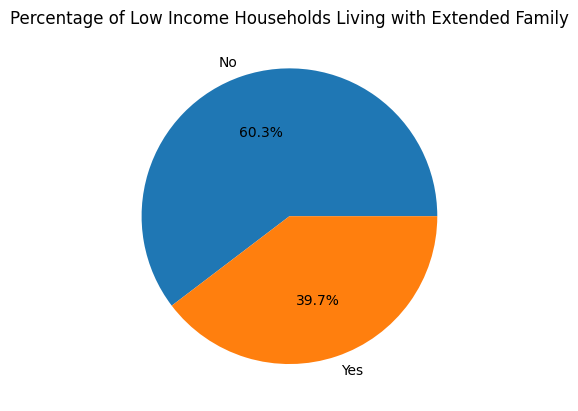

In [23]:
df['IsLivingWithExtendedFamily'].value_counts().plot.pie(
    autopct = '%1.1f%%',
    ylabel = '',
    title = 'Percentage of Low Income Households Living with Extended Family'
)

Getting number of low income households from Bulacan that have a student.

In [24]:
count = (df['IsStudentInHousehold'] == 'Yes').sum()
print(f'Number of low income households with students: {count}')

Number of low income households with students: 57


Visualizing the number of low income households from Bulacan that have a student and those that don't have a student.

<Axes: title={'center': 'Percentage of Low Income Households with Students'}>

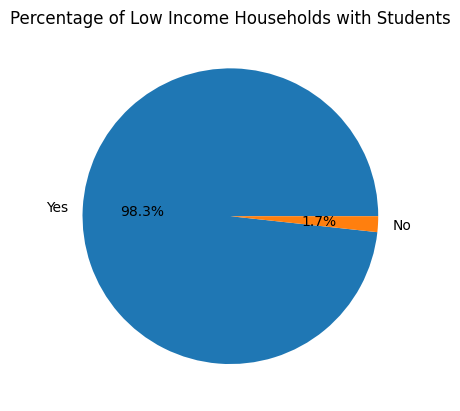

In [25]:
df['IsStudentInHousehold'].value_counts().plot.pie(
    autopct = '%1.1f%%',
    ylabel = '',
    title = 'Percentage of Low Income Households with Students'
)

Getting average bill of the low income households from bulacan.

In [26]:
avg_bill_household = df['avg_bill'].mean()
print(f'The average bill of the low income households is {avg_bill_household}')

The average bill of the low income households is 3498.948275862069


Getting average budget of the low income households from bulacan.

In [27]:
avg_budget_household = df['HouseholdElectricityBudget'].mean()
print(f'The average budget of the low income households is {avg_budget_household}')

The average budget of the low income households is 2327.0862068965516


Conclusion:  The average low income household is spending more on electricity than they have budgeted.

Getting average bill of the low income households with students from bulacan.



In [28]:
df[['IsStudentInHousehold', 'avg_bill']].groupby('IsStudentInHousehold').mean()

,avg_bill
IsStudentInHousehold,
No,1252.000000
Yes,3538.368421


Conclusion:  The average low-income household with a student from Bulacan has a higher average bill than those without a student at home.

Getting how many low income households from Bulacan stuggle to find money for their electricity bill per struggling frequency.



In [29]:
df['StruggleToFindMoneyForElectricBillFrequency'].value_counts()

,count
StruggleToFindMoneyForElectricBillFrequency,
Sometimes,26
Always,11
Often,10
Very Often,8
Never,3


Visualizing how many low income households from Bulacan stuggle to find money for their electricity bill per struggling frequency.

<Axes: title={'center': 'Frequency of Low-Income Households Struggling to Pay Electric Bill'}, xlabel='Frequency', ylabel='Count of Households'>

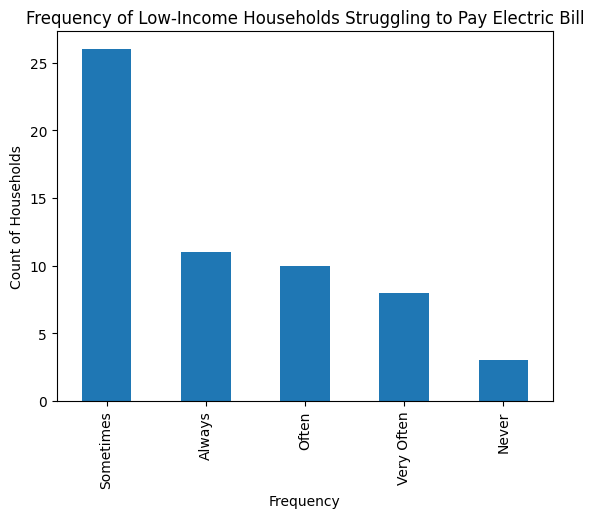

In [30]:
df['StruggleToFindMoneyForElectricBillFrequency'] \
  .value_counts() \
  .plot.bar(
      title = 'Frequency of Low-Income Households Struggling to Pay Electric Bill',
      xlabel = 'Frequency',
      ylabel = 'Count of Households'
  )

Getting how many low income households from Bulacan stuggle to pay the electricity bill per struggling frequency.

In [31]:
df['MonthlyElectricBillPayFailureFrequency'].value_counts()

,count
MonthlyElectricBillPayFailureFrequency,
Sometimes,31
Never,12
Often,9
Very Often,4
Always,2


Visualizing how many low income households from Bulacan stuggle to pay the electricity bill per struggling frequency.

<Axes: title={'center': 'Frequency of Low-Income Households Failing to Pay Electric Bill'}, xlabel='Frequency', ylabel='Count of Households'>

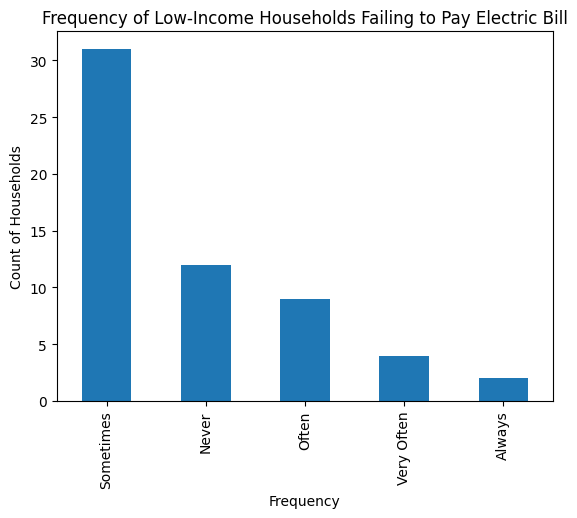

In [32]:
df['MonthlyElectricBillPayFailureFrequency'] \
  .value_counts() \
  .plot.bar(
      title = 'Frequency of Low-Income Households Failing to Pay Electric Bill',
      xlabel = 'Frequency',
      ylabel = 'Count of Households'
  )

Getting number of low income households that have a TV.  Doing the same for each other essential applicance of refrigerator, rice cooker, and washing machine.

In [33]:
count_with_TV = df['OwnedAppliances'].str.contains('TV').sum()
print(f'The number of households with TV is {count_with_TV}')

count_with_Refrigerator = df['OwnedAppliances'].str.contains('Refrigerator').sum()
print(f'The number of households with Refrigerator is {count_with_Refrigerator}')

count_with_Rice_Cooker = df['OwnedAppliances'].str.contains('Rice Cooker').sum()
print(f'The number of households with Rice Cooker is {count_with_Rice_Cooker}')

count_with_Washing_Machine = df['OwnedAppliances'].str.contains('Washing Machine').sum()
print(f'The number of households with Washing Machine is {count_with_Washing_Machine}')

The number of households with TV is 55
The number of households with Refrigerator is 42
The number of households with Rice Cooker is 33
The number of households with Washing Machine is 51


Getting number of low income households that have these luxury of having these appliances.

1. Electric Water Dispenser
2. Air Conditioner

In [34]:
count_essential = (
    df['OwnedAppliances'].str.contains('Electric Water Dispenser')
  & df['OwnedAppliances'].str.contains('Air Conditioner')).sum()
print(f'The number of households with all the essential appliances is {count_essential}')

The number of households with all the essential appliances is 6


Getting number of low income households in Bulacan that have a student and either a laptop or desktop computer.

In [35]:
conn = sqlite3.connect('Survey_Database.db')
cursor = conn.cursor()

query = """
SELECT COUNT(*) AS NumberOfStudentsWithAtLeast
FROM With_Students ws
WHERE ws.HouseholdMonthlySalaryRange = 'Less than Php 21,194'
  AND (ws.HouseholdStudentsHave LIKE '%Laptop%'
        OR  ws.HouseholdStudentsHave LIKE '%Desktop Computer%');
"""

cursor.execute(query)
row = cursor.fetchone()
count = row[0]

print(f'Number of students in low income households who has at least a laptop or desktop computer:  {count}')

conn.close()

Number of students in low income households who has at least a laptop or desktop computer:  43


#Conclusion

Many households earning less than 21,194 php (low-income) in Bulacan with a student sometimes struggles to pay their electric bills.  Those with students have electric bills nearly three times higher than those without students.  Most low-income households do not have at least one essential appliance.  More than a third of them live with extended family.